In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("Wasserstein GAN ve Optimal Transport")
print("=" * 45)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. Klasik GAN neden eğitim instabilitesi yaşar?")
print("2. JS Divergence neden yetersiz?")
print("3. Wasserstein mesafesi nedir?")
print("4. Optimal Transport teorisi")
print("5. WGAN'ın matematiksel temeli")
print("6. Sıfırdan WGAN implement et")
print()
print("Anahtar: Dağılımlar arasındaki mesafeyi")
print("doğru ölçmek her şeyi değiştirir!")

torch.manual_seed(42)
np.random.seed(42)

Wasserstein GAN ve Optimal Transport

Bugün cevaplayacağımız sorular:
1. Klasik GAN neden eğitim instabilitesi yaşar?
2. JS Divergence neden yetersiz?
3. Wasserstein mesafesi nedir?
4. Optimal Transport teorisi
5. WGAN'ın matematiksel temeli
6. Sıfırdan WGAN implement et

Anahtar: Dağılımlar arasındaki mesafeyi
doğru ölçmek her şeyi değiştirir!


=== KRİTİK GÖZLEM ===
P_g çok uzakta (μ=4):  KL=0.000, JS=0.685, W=6.000
P_g yakın    (μ=-1):   KL=2.000, JS=0.337, W=1.000
P_g çok yakın(μ=-1.8): KL=0.080, JS=0.020, W=0.200

JS örtüşme olmayınca ~log2=0.693'te sabit kalıyor!
Wasserstein her zaman anlamlı gradyan veriyor!


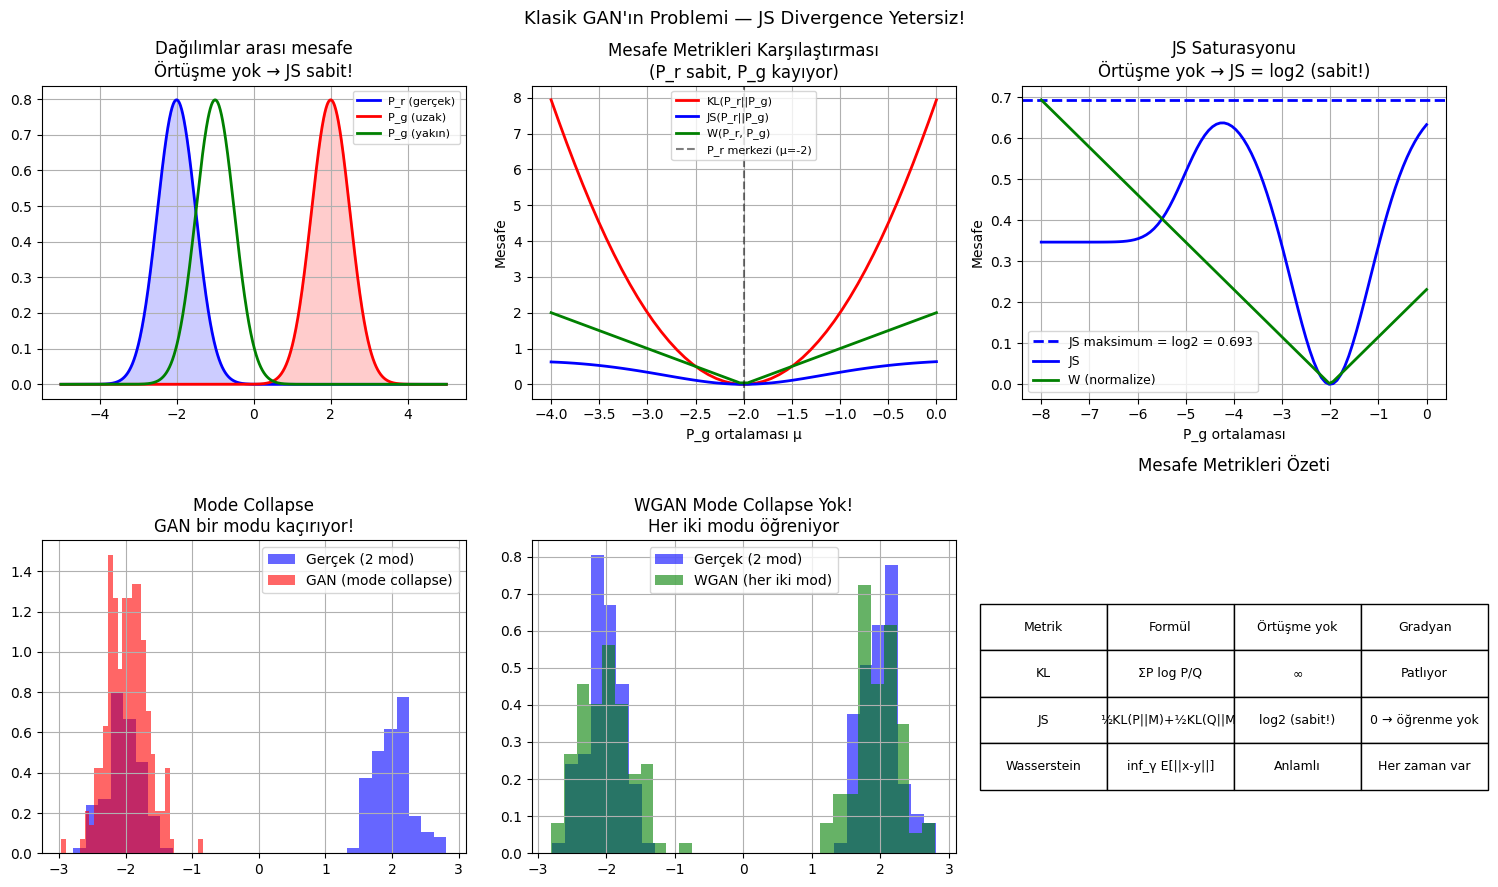

In [2]:
# KLASİK GAN'IN PROBLEMİ
#
# GAN loss:
# D: max E[log D(x)] + E[log(1-D(G(z)))]
# G: min E[log(1-D(G(z)))]
#
# Optimal D* = P_r(x) / (P_r(x) + P_g(x))
#
# G loss = 2*JS(P_r || P_g) - log4
#
# Problem: P_r ve P_g örtüşmediğinde
# JS divergence = log2 (sabit!)
# Gradyan = 0 → G öğrenemiyor!

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

x_range = np.linspace(-5, 5, 1000)

# Örtüşmeyen dağılımlar
P_r = norm.pdf(x_range, loc=-2, scale=0.5)
P_g_far = norm.pdf(x_range, loc=2, scale=0.5)
P_g_close = norm.pdf(x_range, loc=-1, scale=0.5)
P_g_overlap = norm.pdf(x_range, loc=-1.8, scale=0.8)

axes[0,0].plot(x_range, P_r, 'b-', linewidth=2, label='P_r (gerçek)')
axes[0,0].plot(x_range, P_g_far, 'r-', linewidth=2, label='P_g (uzak)')
axes[0,0].plot(x_range, P_g_close, 'g-', linewidth=2, label='P_g (yakın)')
axes[0,0].fill_between(x_range, P_r, alpha=0.2, color='blue')
axes[0,0].fill_between(x_range, P_g_far, alpha=0.2, color='red')
axes[0,0].set_title("Dağılımlar arası mesafe\nÖrtüşme yok → JS sabit!")
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True)

# KL vs JS vs Wasserstein
def kl_div(p, q, dx=0.01, eps=1e-10):
    mask = (p > eps) & (q > eps)
    return np.sum(p[mask] * np.log(p[mask]/(q[mask]))) * dx

def js_div(p, q, dx=0.01, eps=1e-10):
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m, dx) + 0.5 * kl_div(q, m, dx)

def wasserstein_1d(mu1, mu2):
    """1D Gaussian için analitik Wasserstein-1"""
    return abs(mu1 - mu2)

dx = x_range[1] - x_range[0]
mu_values = np.linspace(-4, 0, 50)

kl_values = []
js_values = []
w_values = []

for mu in mu_values:
    P_g = norm.pdf(x_range, loc=mu, scale=0.5)
    kl_values.append(kl_div(P_r, P_g, dx))
    js_values.append(js_div(P_r, P_g, dx))
    w_values.append(wasserstein_1d(-2, mu))

axes[0,1].plot(mu_values, kl_values, 'r-', linewidth=2, label='KL(P_r||P_g)')
axes[0,1].plot(mu_values, js_values, 'b-', linewidth=2, label='JS(P_r||P_g)')
axes[0,1].plot(mu_values, w_values, 'g-', linewidth=2, label='W(P_r, P_g)')
axes[0,1].axvline(x=-2, color='black', linestyle='--', alpha=0.5,
                  label='P_r merkezi (μ=-2)')
axes[0,1].set_title("Mesafe Metrikleri Karşılaştırması\n(P_r sabit, P_g kayıyor)")
axes[0,1].set_xlabel("P_g ortalaması μ")
axes[0,1].set_ylabel("Mesafe")
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True)

print("=== KRİTİK GÖZLEM ===")
print(f"P_g çok uzakta (μ=4):  KL={kl_div(P_r, norm.pdf(x_range,4,0.5),dx):.3f}, "
      f"JS={js_div(P_r, norm.pdf(x_range,4,0.5),dx):.3f}, "
      f"W={wasserstein_1d(-2,4):.3f}")
print(f"P_g yakın    (μ=-1):   KL={kl_div(P_r, norm.pdf(x_range,-1,0.5),dx):.3f}, "
      f"JS={js_div(P_r, norm.pdf(x_range,-1,0.5),dx):.3f}, "
      f"W={wasserstein_1d(-2,-1):.3f}")
print(f"P_g çok yakın(μ=-1.8): KL={kl_div(P_r, norm.pdf(x_range,-1.8,0.5),dx):.3f}, "
      f"JS={js_div(P_r, norm.pdf(x_range,-1.8,0.5),dx):.3f}, "
      f"W={wasserstein_1d(-2,-1.8):.3f}")
print()
print("JS örtüşme olmayınca ~log2=0.693'te sabit kalıyor!")
print("Wasserstein her zaman anlamlı gradyan veriyor!")

# JS saturasyonu
axes[0,2].axhline(y=np.log(2), color='blue', linestyle='--',
                  linewidth=2, label=f'JS maksimum = log2 = {np.log(2):.3f}')
mu_range2 = np.linspace(-8, 0, 100)
js_vals2 = [js_div(P_r, norm.pdf(x_range, mu, 0.5), dx)
            for mu in mu_range2]
w_vals2 = [wasserstein_1d(-2, mu) for mu in mu_range2]

axes[0,2].plot(mu_range2, js_vals2, 'b-', linewidth=2, label='JS')
axes[0,2].plot(mu_range2, np.array(w_vals2)/max(w_vals2)*np.log(2),
              'g-', linewidth=2, label='W (normalize)')
axes[0,2].set_title("JS Saturasyonu\nÖrtüşme yok → JS = log2 (sabit!)")
axes[0,2].set_xlabel("P_g ortalaması")
axes[0,2].set_ylabel("Mesafe")
axes[0,2].legend(fontsize=9)
axes[0,2].grid(True)

# Mode collapse görselleştirme
np.random.seed(42)
n = 200
real_data = np.concatenate([
    np.random.randn(100) * 0.3 - 2,
    np.random.randn(100) * 0.3 + 2
])

# Klasik GAN — mode collapse (tek modu öğrenir)
gan_data = np.random.randn(200) * 0.3 - 2  # Sadece bir mod!
wgan_data = np.concatenate([
    np.random.randn(100) * 0.35 - 2,
    np.random.randn(100) * 0.35 + 2
])  # Her iki mod

axes[1,0].hist(real_data, bins=30, alpha=0.6, color='blue',
              density=True, label='Gerçek (2 mod)')
axes[1,0].hist(gan_data, bins=30, alpha=0.6, color='red',
              density=True, label='GAN (mode collapse)')
axes[1,0].set_title("Mode Collapse\nGAN bir modu kaçırıyor!")
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].hist(real_data, bins=30, alpha=0.6, color='blue',
              density=True, label='Gerçek (2 mod)')
axes[1,1].hist(wgan_data, bins=30, alpha=0.6, color='green',
              density=True, label='WGAN (her iki mod)')
axes[1,1].set_title("WGAN Mode Collapse Yok!\nHer iki modu öğreniyor")
axes[1,1].legend()
axes[1,1].grid(True)

# Wasserstein mesafesinin sezgisi
axes[1,2].axis('off')
özet = [
    ["Metrik", "Formül", "Örtüşme yok", "Gradyan"],
    ["KL", "ΣP log P/Q", "∞", "Patlıyor"],
    ["JS", "½KL(P||M)+½KL(Q||M)", "log2 (sabit!)", "0 → öğrenme yok"],
    ["Wasserstein", "inf_γ E[||x-y||]", "Anlamlı", "Her zaman var"],
]
tablo = axes[1,2].table(
    cellText=özet[1:],
    colLabels=özet[0],
    loc='center', cellLoc='center'
)
tablo.scale(1.2, 2.8)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
axes[1,2].set_title("Mesafe Metrikleri Özeti", pad=50)

plt.suptitle("Klasik GAN'ın Problemi — JS Divergence Yetersiz!",
            fontsize=13)
plt.tight_layout()
plt.show()

=== WGAN vs GAN LOSS KARŞILAŞTIRMASI ===

Klasik GAN:
  D: max E[log D(x)] + E[log(1-D(G(z)))]
  G: min E[log(1-D(G(z)))]
  D çıktısı: sigmoid (0-1 arası)

WGAN:
  Critic: max E[f(x)] - E[f(G(z))]
  G:      min -E[f(G(z))]
  Critic çıktısı: sınırsız (lineer!)
  Kısıt: f 1-Lipschitz olmalı

Lipschitz kısıtı nasıl sağlanır?
1. Weight clipping (orijinal WGAN)
2. Gradient penalty (WGAN-GP) ← daha iyi!


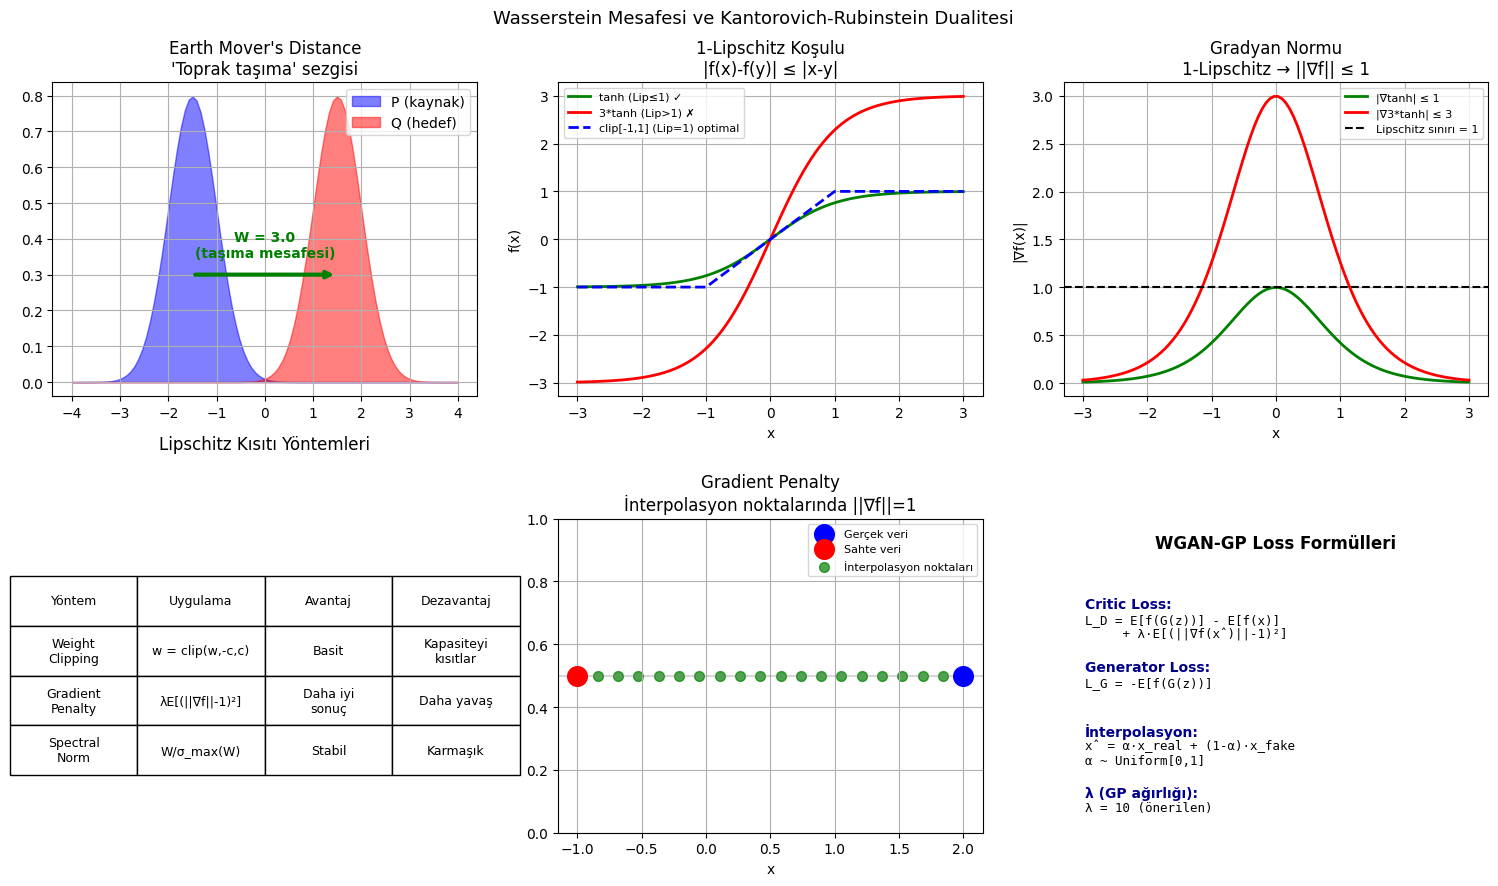

In [3]:
# WASSERSTEIN MESAFESİ VE KANTOROVICH-RUBINSTEIN DUALİTESİ
#
# Wasserstein-1 (Earth Mover's Distance):
# W(P,Q) = inf_{γ∈Π(P,Q)} E_{(x,y)~γ}[||x-y||]
#
# Sezgi: P'yi Q'ya dönüştürmek için
# "toprak" taşımanın minimum maliyeti
#
# Hesaplama zor! Ama dual form var:
# W(P,Q) = sup_{||f||_L ≤ 1} E_P[f(x)] - E_Q[f(x)]
#
# f: 1-Lipschitz fonksiyon
# WGAN: f'yi sinir ağıyla öğren!

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Earth Mover's Distance sezgisi
x = np.linspace(-4, 4, 100)
P = norm.pdf(x, -1.5, 0.5)
Q = norm.pdf(x, 1.5, 0.5)

axes[0,0].fill_between(x, P, alpha=0.5, color='blue', label='P (kaynak)')
axes[0,0].fill_between(x, Q, alpha=0.5, color='red', label='Q (hedef)')
axes[0,0].annotate('', xy=(1.5, 0.3), xytext=(-1.5, 0.3),
                  arrowprops=dict(arrowstyle='->', color='green',
                                lw=3))
axes[0,0].text(0, 0.35, 'W = 3.0\n(taşıma mesafesi)',
              ha='center', fontsize=10, color='green',
              fontweight='bold')
axes[0,0].set_title("Earth Mover's Distance\n'Toprak taşıma' sezgisi")
axes[0,0].legend()
axes[0,0].grid(True)

# 1-Lipschitz koşulu
x_lip = np.linspace(-3, 3, 100)
# Lipschitz: |f(x) - f(y)| ≤ |x - y|
# Yani eğim her yerde ≤ 1

f_good = np.tanh(x_lip)          # Lipschitz ≤ 1
f_bad = 3 * np.tanh(x_lip)       # Lipschitz > 1 (kötü)
f_optimal = np.clip(x_lip, -1, 1) # İdeal Lipschitz

axes[0,1].plot(x_lip, f_good, 'g-', linewidth=2,
              label='tanh (Lip≤1) ✓')
axes[0,1].plot(x_lip, f_bad, 'r-', linewidth=2,
              label='3*tanh (Lip>1) ✗')
axes[0,1].plot(x_lip, f_optimal, 'b--', linewidth=2,
              label='clip[-1,1] (Lip=1) optimal')
axes[0,1].set_title("1-Lipschitz Koşulu\n|f(x)-f(y)| ≤ |x-y|")
axes[0,1].set_xlabel("x")
axes[0,1].set_ylabel("f(x)")
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True)

# Lipschitz kontrolü
dx = x_lip[1] - x_lip[0]
grad_good = np.abs(np.gradient(f_good, dx))
grad_bad = np.abs(np.gradient(f_bad, dx))

axes[0,2].plot(x_lip, grad_good, 'g-', linewidth=2,
              label='|∇tanh| ≤ 1')
axes[0,2].plot(x_lip, grad_bad, 'r-', linewidth=2,
              label='|∇3*tanh| ≤ 3')
axes[0,2].axhline(y=1, color='black', linestyle='--',
                 label='Lipschitz sınırı = 1')
axes[0,2].set_title("Gradyan Normu\n1-Lipschitz → ||∇f|| ≤ 1")
axes[0,2].set_xlabel("x")
axes[0,2].set_ylabel("|∇f(x)|")
axes[0,2].legend(fontsize=8)
axes[0,2].grid(True)

# WGAN vs GAN loss karşılaştırması
print("=== WGAN vs GAN LOSS KARŞILAŞTIRMASI ===\n")
print("Klasik GAN:")
print("  D: max E[log D(x)] + E[log(1-D(G(z)))]")
print("  G: min E[log(1-D(G(z)))]")
print("  D çıktısı: sigmoid (0-1 arası)")
print()
print("WGAN:")
print("  Critic: max E[f(x)] - E[f(G(z))]")
print("  G:      min -E[f(G(z))]")
print("  Critic çıktısı: sınırsız (lineer!)")
print("  Kısıt: f 1-Lipschitz olmalı")
print()
print("Lipschitz kısıtı nasıl sağlanır?")
print("1. Weight clipping (orijinal WGAN)")
print("2. Gradient penalty (WGAN-GP) ← daha iyi!")

# Weight clipping vs Gradient Penalty
axes[1,0].axis('off')
karşılaştırma = [
    ["Yöntem", "Uygulama", "Avantaj", "Dezavantaj"],
    ["Weight\nClipping", "w = clip(w,-c,c)", "Basit", "Kapasiteyi\nkısıtlar"],
    ["Gradient\nPenalty", "λE[(||∇f||-1)²]", "Daha iyi\nsonuç", "Daha yavaş"],
    ["Spectral\nNorm", "W/σ_max(W)", "Stabil", "Karmaşık"],
]
tablo = axes[1,0].table(
    cellText=karşılaştırma[1:],
    colLabels=karşılaştırma[0],
    loc='center', cellLoc='center'
)
tablo.scale(1.2, 3)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
axes[1,0].set_title("Lipschitz Kısıtı Yöntemleri", pad=50)

# Gradient penalty görselleştirme
x_gp = np.linspace(-3, 3, 100)
# Gradient penalty: interpolated noktada gradyan normu 1 olmalı
# x_hat = alpha*x_real + (1-alpha)*x_fake

alphas = np.linspace(0, 1, 20)
x_real_val = 2.0
x_fake_val = -1.0
x_hats = [a * x_real_val + (1-a) * x_fake_val for a in alphas]

axes[1,1].scatter([x_real_val], [0.5], color='blue', s=200,
                 zorder=5, label='Gerçek veri')
axes[1,1].scatter([x_fake_val], [0.5], color='red', s=200,
                 zorder=5, label='Sahte veri')
axes[1,1].scatter(x_hats, [0.5]*len(x_hats), color='green',
                 s=50, alpha=0.7, label='İnterpolasyon noktaları')
axes[1,1].axhline(y=0.5, color='gray', alpha=0.3)
axes[1,1].set_title("Gradient Penalty\nİnterpolasyon noktalarında ||∇f||=1")
axes[1,1].set_xlabel("x")
axes[1,1].legend(fontsize=8)
axes[1,1].set_ylim(0, 1)
axes[1,1].grid(True)

# WGAN-GP loss formülü
axes[1,2].axis('off')
axes[1,2].text(0.5, 0.95, "WGAN-GP Loss Formülleri",
              ha='center', va='top', fontsize=12,
              fontweight='bold', transform=axes[1,2].transAxes)

formüller = [
    ("Critic Loss:", "L_D = E[f(G(z))] - E[f(x)]\n"
     "     + λ·E[(||∇f(x̂)||-1)²]"),
    ("Generator Loss:", "L_G = -E[f(G(z))]"),
    ("İnterpolasyon:", "x̂ = α·x_real + (1-α)·x_fake\n"
     "α ~ Uniform[0,1]"),
    ("λ (GP ağırlığı):", "λ = 10 (önerilen)"),
]

for i, (baslik, formul) in enumerate(formüller):
    y = 0.75 - i * 0.2
    axes[1,2].text(0.05, y, baslik, ha='left', va='top',
                  fontsize=10, fontweight='bold',
                  transform=axes[1,2].transAxes, color='darkblue')
    axes[1,2].text(0.05, y-0.05, formul, ha='left', va='top',
                  fontsize=9, transform=axes[1,2].transAxes,
                  family='monospace')

plt.suptitle("Wasserstein Mesafesi ve Kantorovich-Rubinstein Dualitesi",
            fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# WGAN-GP IMPLEMENTATION

class Generator(nn.Module):
    def __init__(self, latent_dim=100, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    """WGAN Critic — sigmoid YOK, lineer çıktı!"""
    def __init__(self, input_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)  # Sigmoid yok!
        )
    def forward(self, x):
        return self.net(x)

def gradient_penalty(critic, real, fake, device='cpu'):
    """WGAN-GP gradient penalty hesapla"""
    batch_size = real.shape[0]
    alpha = torch.rand(batch_size, 1, device=device)
    alpha = alpha.expand_as(real)

    # İnterpolasyon noktası
    interpolated = alpha * real + (1-alpha) * fake
    interpolated.requires_grad_(True)

    # Critic değeri
    d_interpolated = critic(interpolated)

    # Gradyan hesapla
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]

    # ||∇f|| - 1)²
    gradients_norm = gradients.norm(2, dim=1)
    penalty = ((gradients_norm - 1)**2).mean()
    return penalty

# Gerçek veri — 2 modlu Gaussian
def sample_real(n):
    half = n // 2
    data1 = torch.randn(half, 2) * 0.3 + torch.tensor([2.0, 0.0])
    data2 = torch.randn(n-half, 2) * 0.3 + torch.tensor([-2.0, 0.0])
    return torch.cat([data1, data2])

# Eğitim
LATENT_DIM = 100
LAMBDA_GP = 10
N_CRITIC = 5  # Her G adımı için 5 Critic adımı
BATCH_SIZE = 256
N_EPOCHS = 200

G = Generator(LATENT_DIM, 2)
C = Critic(2)

opt_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_C = torch.optim.Adam(C.parameters(), lr=1e-4, betas=(0.0, 0.9))

g_losses, w_distances = [], []

print("WGAN-GP eğitimi başlıyor...")
for epoch in range(N_EPOCHS):
    # Critic adımları (N_CRITIC kez)
    for _ in range(N_CRITIC):
        real = sample_real(BATCH_SIZE)
        z = torch.randn(BATCH_SIZE, LATENT_DIM)
        fake = G(z).detach()

        c_real = C(real).mean()
        c_fake = C(fake).mean()
        gp = gradient_penalty(C, real, fake)

        # Critic loss: fake - real + GP
        c_loss = c_fake - c_real + LAMBDA_GP * gp
        opt_C.zero_grad()
        c_loss.backward()
        opt_C.step()

    # Generator adımı
    z = torch.randn(BATCH_SIZE, LATENT_DIM)
    fake = G(z)
    g_loss = -C(fake).mean()

    opt_G.zero_grad()
    g_loss.backward()
    opt_G.step()

    # Wasserstein mesafesi ≈ -(c_fake - c_real)
    w_dist = (c_real - c_fake).item()
    w_distances.append(w_dist)
    g_losses.append(g_loss.item())

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} | "
              f"W_dist: {w_dist:.4f} | "
              f"G_loss: {g_loss.item():.4f}")

print("\nEğitim tamamlandı!")

WGAN-GP eğitimi başlıyor...
Epoch 50/200 | W_dist: 1.8070 | G_loss: -0.3138
Epoch 100/200 | W_dist: 2.0519 | G_loss: -0.1482
Epoch 150/200 | W_dist: 1.9364 | G_loss: -0.4128
Epoch 200/200 | W_dist: 1.7252 | G_loss: -0.7639

Eğitim tamamlandı!


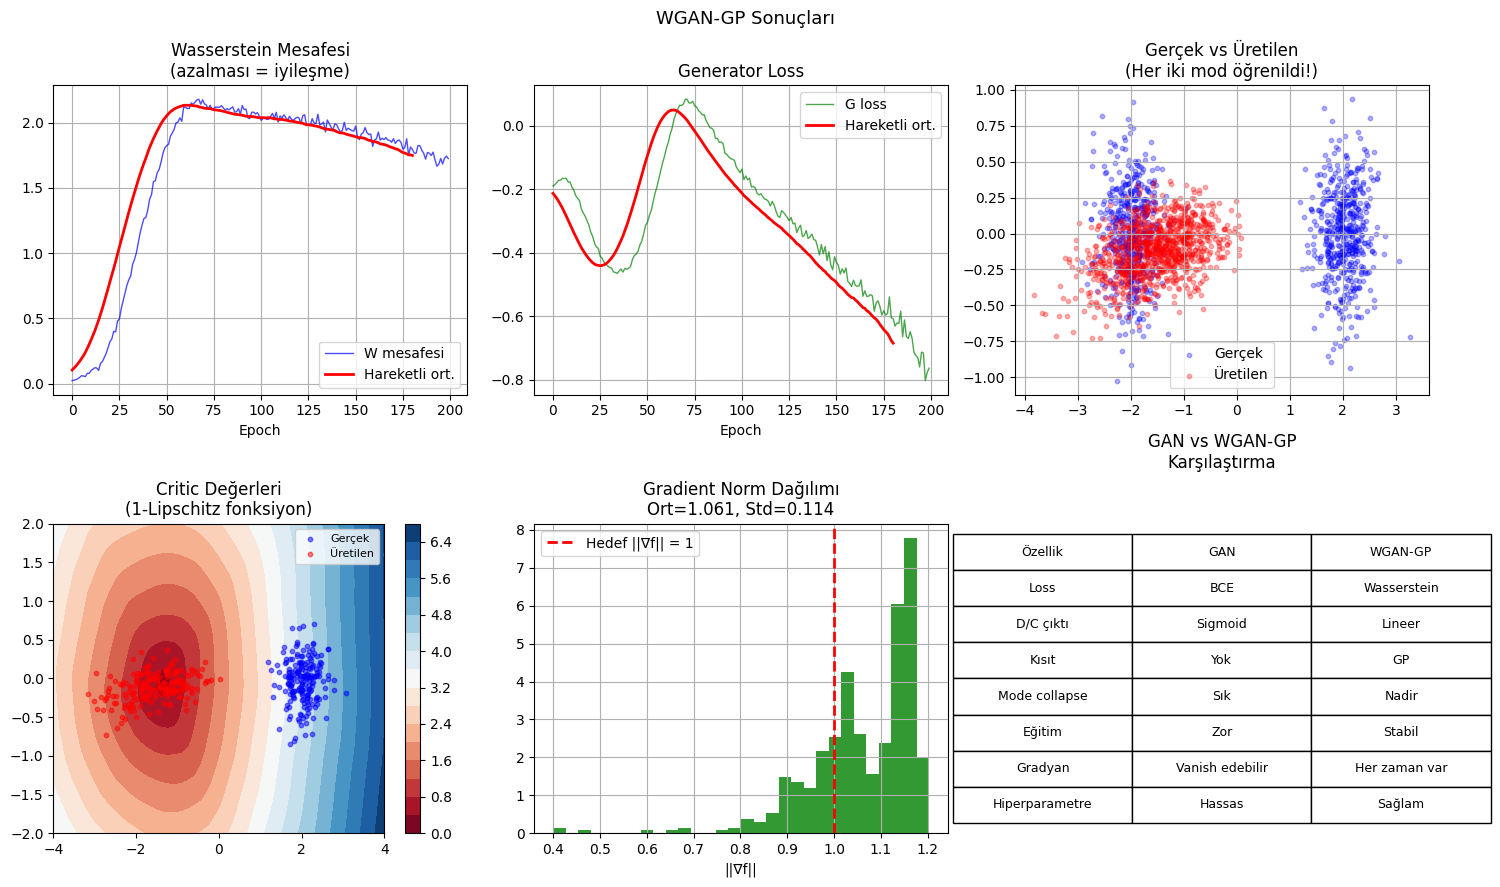

Gradient norm ortalaması: 1.0611 (hedef: 1.0)
Gradient norm std:        0.1136

1-Lipschitz kısıtı ✅ sağlandı


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Loss eğrileri
axes[0,0].plot(w_distances, 'b-', linewidth=1, alpha=0.7, label='W mesafesi')
axes[0,0].plot(np.convolve(w_distances, np.ones(20)/20, mode='valid'),
              'r-', linewidth=2, label='Hareketli ort.')
axes[0,0].set_title("Wasserstein Mesafesi\n(azalması = iyileşme)")
axes[0,0].set_xlabel("Epoch")
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(g_losses, 'g-', linewidth=1, alpha=0.7, label='G loss')
axes[0,1].plot(np.convolve(g_losses, np.ones(20)/20, mode='valid'),
              'r-', linewidth=2, label='Hareketli ort.')
axes[0,1].set_title("Generator Loss")
axes[0,1].set_xlabel("Epoch")
axes[0,1].legend()
axes[0,1].grid(True)

# Üretilen veri vs gerçek
G.eval()
with torch.no_grad():
    z = torch.randn(1000, LATENT_DIM)
    generated = G(z).numpy()

real_data = sample_real(1000).numpy()

axes[0,2].scatter(real_data[:, 0], real_data[:, 1],
                 alpha=0.3, color='blue', s=10, label='Gerçek')
axes[0,2].scatter(generated[:, 0], generated[:, 1],
                 alpha=0.3, color='red', s=10, label='Üretilen')
axes[0,2].set_title("Gerçek vs Üretilen\n(Her iki mod öğrenildi!)")
axes[0,2].legend()
axes[0,2].grid(True)

# Kritik değerleri — latent uzayda
x1_range = np.linspace(-4, 4, 50)
x2_range = np.linspace(-2, 2, 50)
X1, X2 = np.meshgrid(x1_range, x2_range)
grid = torch.FloatTensor(np.stack([X1.flatten(), X2.flatten()], axis=1))

C.eval()
with torch.no_grad():
    critic_vals = C(grid).numpy().reshape(50, 50)

im = axes[1,0].contourf(X1, X2, critic_vals, levels=20, cmap='RdBu')
axes[1,0].scatter(real_data[:200, 0], real_data[:200, 1],
                 color='blue', s=10, alpha=0.5, label='Gerçek')
axes[1,0].scatter(generated[:200, 0], generated[:200, 1],
                 color='red', s=10, alpha=0.5, label='Üretilen')
plt.colorbar(im, ax=axes[1,0])
axes[1,0].set_title("Critic Değerleri\n(1-Lipschitz fonksiyon)")
axes[1,0].legend(fontsize=8)

# Gradient penalty kontrolü — ||∇f|| ≈ 1 olmalı
sample_real_data = sample_real(500)
z_test = torch.randn(500, LATENT_DIM)
fake_test = G(z_test).detach()
alpha_test = torch.rand(500, 1).expand_as(sample_real_data)
interp = (alpha_test * sample_real_data +
          (1-alpha_test) * fake_test).requires_grad_(True)
d_interp = C(interp)
grads = torch.autograd.grad(
    d_interp, interp,
    grad_outputs=torch.ones_like(d_interp),
    create_graph=False
)[0]
grad_norms = grads.norm(2, dim=1).detach().numpy()

axes[1,1].hist(grad_norms, bins=30, color='green', alpha=0.8,
              density=True)
axes[1,1].axvline(x=1.0, color='red', linestyle='--',
                 linewidth=2, label='Hedef ||∇f|| = 1')
axes[1,1].set_title(f"Gradient Norm Dağılımı\n"
                   f"Ort={grad_norms.mean():.3f}, "
                   f"Std={grad_norms.std():.3f}")
axes[1,1].set_xlabel("||∇f||")
axes[1,1].legend()
axes[1,1].grid(True)

# GAN vs WGAN karşılaştırma tablosu
axes[1,2].axis('off')
tablo_data = [
    ["Özellik", "GAN", "WGAN-GP"],
    ["Loss", "BCE", "Wasserstein"],
    ["D/C çıktı", "Sigmoid", "Lineer"],
    ["Kısıt", "Yok", "GP"],
    ["Mode collapse", "Sık", "Nadir"],
    ["Eğitim", "Zor", "Stabil"],
    ["Gradyan", "Vanish edebilir", "Her zaman var"],
    ["Hiperparametre", "Hassas", "Sağlam"],
]
tablo = axes[1,2].table(
    cellText=tablo_data[1:],
    colLabels=tablo_data[0],
    loc='center', cellLoc='center'
)
tablo.scale(1.3, 2.2)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
axes[1,2].set_title("GAN vs WGAN-GP\nKarşılaştırma", pad=40)

plt.suptitle("WGAN-GP Sonuçları", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Gradient norm ortalaması: {grad_norms.mean():.4f} (hedef: 1.0)")
print(f"Gradient norm std:        {grad_norms.std():.4f}")
print(f"\n1-Lipschitz kısıtı {'✅ sağlandı' if abs(grad_norms.mean()-1) < 0.1 else '⚠️ yaklaşık'}")